> ## 📘 Fundamentals required for M2L1 - Multimodal Vector Index
> Before working this notebook, make sure you're comfortable with these — every cell below assumes them:
>
- **Embeddings** — A neural model turns text or an image into a fixed-length vector of numbers (an 'embedding') such that similar MEANINGS end up as NEARBY vectors -- this is what makes semantic search possible at all.
- **Two different embedders for two different modalities** — Text and images can't share one model. This lab uses <b>SentenceTransformer</b> (<code>all-MiniLM-L6-v2</code>, 384 dimensions) for text, and <b>CLIP</b> (<code>clip-vit-base-patch32</code>, 512 dimensions) for images -- each collection's vector size must match its embedder's output size.
- **Cosine similarity & normalization** — <code>normalize_embeddings=True</code> and dividing by <code>.norm()</code> both scale a vector to length 1 -- once vectors are unit-length, a simple dot product IS the cosine similarity. This is the same math from the hybrid-search alpha-scaling explanation.
- **PyTorch basics: <code>torch.no_grad()</code>** — Wrapping inference code in <code>@torch.no_grad()</code> tells PyTorch not to track gradients (which are only needed for training) -- makes embedding generation faster and use less memory.
- **LangChain <code>Document</code> objects** — A <code>Document</code> bundles <code>page_content</code> (the text) with a <code>metadata</code> dict (any extra fields you want to filter/store) -- the standard unit LangChain's vector-store integrations expect.
- **Chroma collections & upsert** — A <b>collection</b> is a named table of vectors inside a Chroma database. <code>upsert</code> = insert-or-update by ID, so re-running the cell won't create duplicates. <code>persist_directory</code> is where the database is saved to disk.
>
> If any of these are new, it's worth a 10-minute detour before continuing — the cell-by-cell notes
> below assume you already know what each one IS, and focus on how this lab USES it.

<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Construct a Multimodal Vector Index**


Estimated time needed: **45** minutes


## Introduction

Retrieval-Augmented Generation (RAG) systems depend critically on the quality of their retrieval layer to produce grounded and contextually accurate responses. In real-world applications, user queries often span heterogeneous data sources, including structured textual information and visual content. As a result, modern RAG pipelines increasingly adopt **multimodal retrieval architectures** capable of indexing and searching across multiple data modalities.

To support these scenarios, multimodal systems encode different data types into dense vector representations that enable efficient similarity-based search. A well-designed retrieval layer ensures that high-quality evidence is identified before any downstream reasoning or generation occurs.

In this lab, you will build the retrieval backbone of a multimodal RAG system for restaurant and food discovery. Using structured outputs from Module 1 together with raw food images, you will construct **vectorized, searchable indexes** that support cross-modal evidence retrieval.

The lab emphasizes **retrieval pipeline engineering**, focusing on how heterogeneous data is transformed, embedded, and organized within scalable vector databases using ChromaDB. This modular design mirrors production RAG systems, where the retrieval layer operates as a reusable component independent of the generation model.

Upon completion, you will have a functional multimodal vector index that forms the foundation for similarity search, metadata-constrained retrieval, and multimodal fusion in subsequent lessons.


## Objectives

After completing this lab, you will be able to:

- Construct retrieval-ready documents from structured restaurant data  
- Generate dense embeddings for both text and image modalities  
- Build separate vector indexes for articles and food images using Chroma  
- Persist multimodal vector databases for downstream retrieval tasks  
- Prepare the retrieval backbone for similarity search and metadata filtering  

These capabilities form the foundation of a production-style multimodal RAG retrieval pipeline.


## Set up the lab environment

In this step, you'll install the core libraries required to build a multimodal retrieval system.

The environment supports both text and image processing and prepares the runtime for vector database construction. These components will be used throughout the module.

The environment includes:

- **PyTorch (CPU)** for model inference and tensor operations  
- **LangChain + Chroma** for vector database construction and persistence  
- **Sentence-Transformers** for generating text embeddings  
- **Transformers (CLIP)** for image embedding support  
- **Pillow and NumPy** for image loading and numerical processing  

After installation completes, the environment will be ready for multimodal vector index construction.


> 📎 **CONCEPT** — Installs this lab's dependencies: PyTorch (CPU build), LangChain + its Chroma integration, and sentence-transformers/transformers (for the text and CLIP embedders) -- pinned to exact versions for reproducibility.

In [1]:
import subprocess, sys
py = sys.executable
subprocess.check_call([py, "-m", "pip", "install", "-q", "torch", "torchvision", "--index-url", "https://download.pytorch.org/whl/cpu"])
subprocess.check_call([py, "-m", "pip", "install", "-q", "langchain==0.3.27", "langchain-community==0.3.31", "langchain-chroma==0.2.6"])
subprocess.check_call([py, "-m", "pip", "install", "-q", "sentence-transformers==2.7.0", "transformers", "pillow", "numpy"])
print("✅ Dependencies installed")

✅ Dependencies installed


## Import core libraries

Next, import the core Python libraries used throughout this lab.

These libraries enable:

- structured data loading and preprocessing  
- embedding model initialization  
- multimodal document construction  
- vector database creation and management  

Successful import confirms that the runtime environment is correctly configured and ready for the retrieval pipeline.


> 📎 **CONCEPT** — Imports everything the notebook needs: standard-library file/path helpers, numpy/torch for the math, PIL for images, and the three key classes -- <code>Chroma</code> (the vector store), <code>Document</code> (LangChain's data unit), <code>SentenceTransformer</code> and <code>CLIPModel</code>/<code>CLIPProcessor</code> (the two embedders).

In [2]:
# ================================
# Import libraries
# ================================

# Standard library
import glob
import json
import os
import shutil
from pathlib import Path

# Third-party library
import numpy as np
import torch
from PIL import Image
from langchain_chroma import Chroma
from langchain_core.documents import Document
from sentence_transformers import SentenceTransformer
from transformers import CLIPModel, CLIPProcessor

print("✅ Environment ready")


c:\Users\AD10209\Downloads\Course RAG AI\.venv\Lib\site-packages\langchain_core\_api\deprecation.py:27: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1
c:\Users\AD10209\Downloads\Course RAG AI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Environment ready


## Prepare the image dataset

Multimodal retrieval systems require both textual and visual evidence.

In this step, you'll perform the following operations:

1. Download the synthetic recipe image dataset  
2. Extract the image archive  
3. Collect image file paths for embedding  

These images will later form the **Restaurant & Food Images database**, which complements the restaurant text database built from structured data.


> 📎 **CONCEPT** — Downloads and unzips the same recipe-images archive used in M1L2, then collects every image file path into <code>image_paths</code> -- this is the raw material for the image side of the index.

In [3]:
# ================================
# Download and prepare image data
# ================================
import urllib.request, zipfile

ZIP_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/5_Rr6ohviItzucyWk6nkrw/synthetic-recipe-images.zip"
ZIP_PATH = "synthetic-recipe-images.zip"
IMG_DIR  = "recipe_images"

if not os.path.exists(ZIP_PATH):
    print("Downloading images...")
    urllib.request.urlretrieve(ZIP_URL, ZIP_PATH)

with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(IMG_DIR)

import glob
image_paths = sorted(glob.glob(f"{IMG_DIR}/**/*.png", recursive=True))
print(f"✅ Images found: {len(image_paths)}")

✅ Images found: 109


## Load the structured data

This module builds directly on the structured outputs produced earlier. Before constructing the multimodal index, load the processed JSON files generated earlier.

You'll load:

- **Structured restaurant data**, which provides the textual retrieval corpus  
- **Augmented recipe data**, which supplies additional metadata for food items  

These structured records will be transformed into retrieval-ready documents in the next step. Maintaining this pipeline connection ensures the multimodal RAG system remains modular and extensible.


> 📎 **CONCEPT** — Loads the TWO JSON files produced by Module 1 (<code>structured_restaurant_data.json</code> from M1L1, <code>augmented_food_recipe.json</code> from M1L2) -- <code>find_json()</code> searches a few likely folder locations so the notebook works whether you're running it standalone or alongside the other M1 labs.

In [4]:
# ================================
# Load structured data from Module 1
# ================================
import os, json

def find_json(name):
    candidates = [
        name,
        os.path.join("..", name),
        os.path.join("..", "M1L1", name),
        os.path.join("..", "M1L2", name),
        os.path.join("..", "M1L3", name),
    ]
    for p in candidates:
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f"Cannot find {name}. Please copy it to {os.getcwd()}")

rest_path = find_json("structured_restaurant_data.json")
recipe_path = find_json("augmented_food_recipe.json")

with open(rest_path, "r", encoding="utf-8") as f:
    restaurants = json.load(f)

with open(recipe_path, "r", encoding="utf-8") as f:
    recipes = json.load(f)

print(f"✅ Loaded restaurants: {len(restaurants)} (from {rest_path})")
print(f"✅ Loaded recipes:     {len(recipes)} (from {recipe_path})")

✅ Loaded restaurants: 125 (from ..\M1L1\structured_restaurant_data.json)
✅ Loaded recipes:     109 (from ..\M1L2\augmented_food_recipe.json)


## Initialize embedding models

To support multimodal retrieval, you need to initialize two specialized embedding models.

The system uses:

- **Sentence-Transformers (384-dimensional)** for restaurant text encoding  
- **CLIP image encoder (512-dimensional)** for food image encoding  

Both embedding outputs are L2-normalized to support cosine similarity search in later retrieval stages. Using modality-appropriate encoders ensures that semantic similarity is preserved within each vector space.


> 📎 **CONCEPT** — Initializes the two embedders described in the fundamentals above: <code>text_model</code> (SentenceTransformer, wrapped in <code>embed_texts()</code> which normalizes output for cosine similarity) and <code>clip_model</code>/<code>clip_processor</code> (wrapped in <code>embed_images()</code>, which also L2-normalizes each image vector).

In [5]:
# ================================
# Initialize embedding models
# ================================

# ---- Text embedding model (384-d) ----
text_model = SentenceTransformer("all-MiniLM-L6-v2")

def embed_texts(texts, batch_size=64):
    return text_model.encode(
        texts,
        batch_size=batch_size,
        show_progress_bar=False,
        normalize_embeddings=True,  # cosine-ready
    ).astype(np.float32)

print("✅ Text embedder ready")


# ---- Image embedding model (512-d) ----
device = "cpu"
clip_name = "openai/clip-vit-base-patch32"
clip_model = CLIPModel.from_pretrained(clip_name).to(device)
clip_processor = CLIPProcessor.from_pretrained(clip_name, use_fast=True)
clip_model.eval()

@torch.no_grad()
def embed_images(paths, batch_size=16):
    vecs = []
    for i in range(0, len(paths), batch_size):
        batch = paths[i:i+batch_size]
        imgs = [Image.open(p).convert("RGB") for p in batch]
        inputs = clip_processor(images=imgs, return_tensors="pt").to(device)
        feats = clip_model.get_image_features(**inputs)          # (B,512)
        feats = feats / feats.norm(dim=-1, keepdim=True)         # cosine-ready
        vecs.append(feats.cpu().numpy().astype(np.float32))
    return np.vstack(vecs)

print("✅ Image embedder ready")


✅ Text embedder ready
✅ Image embedder ready


## Construct multimodal documents

Vector databases operate on structured documents rather than raw files.

In this step, you'll construct two document sets:

1. **Article documents** derived from structured restaurant data  
2. **Image documents** derived from recipe image files  

Each document includes:

- Retrieval text (`page_content`)  
- A unique document identifier  
- Metadata fields that enable filtering and constrained search  

These multimodal documents form the foundation of the retrieval index and will be embedded in the next stage.


> 📎 **CONCEPT** — Builds the two sets of <code>Document</code> objects to index: <code>article_docs</code> (one per restaurant, with cuisine/location in metadata) and <code>image_docs</code> (one per recipe image, with the image file path and recipe id in metadata) -- each gets a guaranteed-unique <code>doc_id</code>.

In [6]:
# ================================
# Build article and image documents
# ================================

# -------- articles --------
article_docs = []

for i, r in enumerate(restaurants):
    name = str(r.get("name", "")).strip()
    if not name:
        continue

    text = (
    f"Restaurant: {name}\n"
    f"Cuisine: {r.get('food_style','')}\n"
    f"Location: {r.get('location','')}"
    )

    # GUARANTEED UNIQUE
    doc_id = f"rest_{i}"

    article_docs.append(
        Document(
            page_content=text.strip(),
            metadata={
                "doc_id": doc_id,
                "cuisine": r.get("food_style"),
                "location": r.get("location"),
                "source": "restaurant",
            },
        )
    )

print("✅ article docs:", len(article_docs))


# -------- images --------
image_docs = []

for i, (p, rec) in enumerate(zip(image_paths, recipes)):
    doc_id = f"img_{i}"

    image_docs.append(
        Document(
            # keeps retrieval results readable
            page_content=rec.get("name", f"recipe image {i}"),
            metadata={
                "doc_id": doc_id,
                "image_path": p,
                "source": "recipe_image",
                "recipe_id": rec.get("id"),
                "cuisine": rec.get("cuisine"),
            },
        )
    )

print("✅ image docs:", len(image_docs))


✅ article docs: 103
✅ image docs: 109


## Construct the vector index 

You'll now construct the retrieval backbone of the multimodal RAG system.

This step performs the following operations:

1. Generate embeddings for both text and image documents  
2. Create separate Chroma collections for each modality  
3. Store vectors together with their metadata  
4. Persist the multimodal index to disk for reuse  

After this step completes, the system is fully prepared for similarity retrieval and metadata filtering in Lesson 2.


> 📎 **CONCEPT** — <b>The indexing step.</b> Sets up a fresh Chroma database directory, then <code>_upsert()</code> embeds and stores both document sets into two separate collections (<code>restaurant_articles</code> and <code>food_images</code>). Finishes by printing a summary and plotting a sample of the indexed food images -- your visual confirmation the multimodal index actually built correctly.

✅ Article DB ready
✅ Image DB ready

MULTIMODAL VECTOR INDEX SUMMARY

Restaurant Articles: 103 docs
----------------------------------------
  [rest_0] Restaurant: Sakura Garden
Cuisine: Kaiseki-lite
Location: Little Tokyo...
  [rest_1] Restaurant: The Golden Hummus
Cuisine: Modern
Location: Glendale, California...
  [rest_2] Restaurant: My Restaurant
Cuisine: Italian
Location: My City...
  [rest_3] Restaurant: CAFE 12 Cafe
Cuisine: American
Location: CUMBERLAND...
  [rest_4] Restaurant: Salt & Sand
Cuisine: Upscale
Location: Manhattan Beach, CA...

Food Images: 109 docs
----------------------------------------


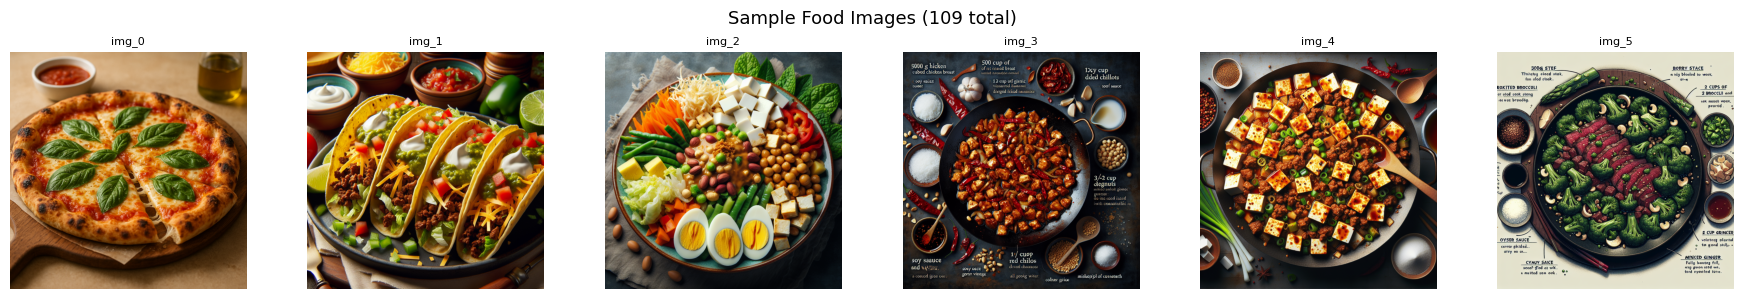


Article DB: 103 vectors  |  Image DB: 109 vectors
🎉 Multimodal Vector Index Construction COMPLETE


In [14]:
import matplotlib.pyplot as plt, gc
DB_DIR = str((Path.home() / "chroma_multimodal").resolve())
try: article_db._client.clear_system_cache(); del article_db, image_db
except Exception: pass
if os.path.isdir(DB_DIR):
    gc.collect()
    try: shutil.rmtree(DB_DIR)
    except PermissionError: pass
def _upsert(name, docs, vecs):
    db = Chroma(collection_name=name, persist_directory=DB_DIR)
    db._collection.upsert(ids=[d.metadata["doc_id"] for d in docs], embeddings=vecs.tolist(),
                           documents=[d.page_content for d in docs], metadatas=[d.metadata for d in docs])
    return db
article_db = _upsert("restaurant_articles", article_docs, embed_texts([d.page_content for d in article_docs]))
print("✅ Article DB ready")
image_db = _upsert("food_images", image_docs, embed_images([d.metadata["image_path"] for d in image_docs]))
print("✅ Image DB ready")
art_count, img_count = article_db._collection.count(), image_db._collection.count()
print(f"\n{'='*60}\nMULTIMODAL VECTOR INDEX SUMMARY\n{'='*60}")
print(f"\nRestaurant Articles: {art_count} docs\n" + "-"*40)
for did, dtxt in zip(*[article_db._collection.peek(5)[k] for k in ("ids","documents")]):
    print(f"  [{did}] {dtxt[:80]}...")
print(f"\nFood Images: {img_count} docs\n" + "-"*40)
peek = image_db._collection.peek(6)
fig, axes = plt.subplots(1, 6, figsize=(18, 3))
fig.suptitle(f"Sample Food Images ({img_count} total)", fontsize=13)
for ax, did, meta in zip(axes.flat, peek["ids"], peek["metadatas"]):
    p = meta.get("image_path", "")
    if os.path.exists(p): ax.imshow(Image.open(p).convert("RGB")); ax.set_title(did, fontsize=8)
    ax.axis("off")
plt.tight_layout(); plt.show()
print(f"\n{'='*60}\nArticle DB: {art_count} vectors  |  Image DB: {img_count} vectors")
print(f"🎉 Multimodal Vector Index Construction COMPLETE\n{'='*60}")

### 📸 Screenshot Submission Requirement

At the end of this lab, take a screenshot of the final code cell and its output, and name it **M2L1_multimodal_vector_index.jpg**.

Your screenshot must clearly show:
- Successful creation of both Chroma collections:
  - `restaurant_articles`
  - `food_images`
- The final completion message:  
  **"Multimodal Vector Index Construction COMPLETE"**

This screenshot will later serve as a component for the assessment.


## Conclusion

In this lab, you built the multimodal retrieval foundation for the restaurant RAG system. You converted structured restaurant data and food images into retrieval-ready documents, generated embeddings, and constructed persistent vector indexes using Chroma.

The multimodal index is now prepared for similarity search and metadata filtering. 


## Authors


[Zikai Dou](https://author.skills.network/instructors/zikai_dou)


Copyright © IBM Corporation. All rights reserved.
